# Libraries

In [1]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import copy
from sklearn.model_selection import train_test_split

import torchvision

import matplotlib.pyplot as plt
from IPython import display
display.set_matplotlib_formats('svg')

from torchsummary import summary

/tmp/ipython-input-57994026.py:14: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  display.set_matplotlib_formats('svg')


In [2]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device

'cuda:0'

# Classification

# Data

In [3]:
from torchvision import datasets, transforms

transform = transforms.ToTensor()

train_ds = datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_ds = datasets.FashionMNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 191kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.56MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 16.7MB/s]


# Loaders

In [4]:
batch_size = 32
train_dataloader = DataLoader(train_ds, batch_size = batch_size, shuffle = True)
test_dataloader = DataLoader(test_ds, batch_size = batch_size, shuffle = False)

In [5]:
x, y = next(iter(train_dataloader))
print(x.shape)  # (batch, 1, 28, 28)
print(y.shape)  # (batch,)

torch.Size([32, 1, 28, 28])
torch.Size([32])


In [6]:
train_ds.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [7]:
img, label = train_ds[0]
print(img.shape)   # (1, 28, 28)
print(label)       # int

torch.Size([1, 28, 28])
9


In [8]:
len(train_ds)   # 60000
len(test_ds)    # 10000

10000

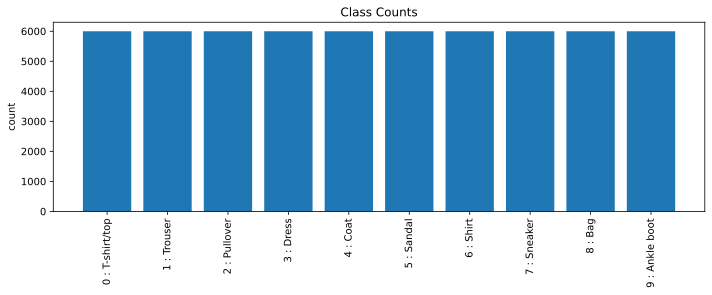

In [9]:
import numpy as np
import matplotlib.pyplot as plt

classes = train_ds.classes
labels = [train_ds[i][1] for i in range(len(train_ds))]

counts = np.bincount(labels, minlength=len(classes))

xticks = [f"{i} : {c}" for i, c in enumerate(classes)]

plt.figure(figsize=(10,4))
plt.bar(np.arange(len(classes)), counts)
plt.xticks(np.arange(len(classes)), xticks, rotation=90)
plt.ylabel("count")
plt.tight_layout()
plt.title('Class Counts')
plt.show()

# Model

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def CreateModel(verbose=False):

  class Net(nn.Module):
    def __init__(self):
      super().__init__()

      def block(cin, cout):
        return nn.Sequential(
          nn.Conv2d(cin, cout, 3, padding=1, bias=False),
          nn.BatchNorm2d(cout),
          nn.ReLU(inplace=True),
          nn.Conv2d(cout, cout, 3, padding=1, bias=False),
          nn.BatchNorm2d(cout),
          nn.ReLU(inplace=True),
        )

      self.b1 = block(1, 64)     # 32x32
      self.b2 = block(64, 128)   # 16x16
      self.b3 = block(128, 256)  # 8x8

      self.pool = nn.MaxPool2d(2)
      self.drop = nn.Dropout(0.3)
      self.gap  = nn.AdaptiveAvgPool2d(1)  # -> (B, C, 1, 1)
      self.fc   = nn.Linear(256, 10)

    def forward(self, x):
      x = self.pool(self.b1(x))
      if verbose: print("b1:", list(x.shape))  # (B,64,16,16)

      x = self.pool(self.b2(x))
      if verbose: print("b2:", list(x.shape))  # (B,128,8,8)

      x = self.pool(self.b3(x))
      if verbose: print("b3:", list(x.shape))  # (B,256,4,4)

      x = self.drop(x)
      x = self.gap(x).squeeze(-1).squeeze(-1)  # (B,256)
      if verbose: print("gap:", list(x.shape))

      x = self.fc(x)
      if verbose: print("out:", list(x.shape))
      return x

  net = Net()
  optimizer = torch.optim.AdamW(net.parameters(), lr=3e-4, weight_decay=5e-4)
  loss_fn = nn.CrossEntropyLoss()
  scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
  return net, loss_fn, optimizer, scheduler

In [11]:
X, y = next(iter(train_dataloader))
net, loss_fn, optimize, scheduler = CreateModel()
y_hat = net(X)
loss = loss_fn(y_hat, y)
loss

tensor(2.3923, grad_fn=<NllLossBackward0>)

In [13]:
summary(net.to(device), (1, 28, 28))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 28, 28]             576
       BatchNorm2d-2           [-1, 64, 28, 28]             128
              ReLU-3           [-1, 64, 28, 28]               0
            Conv2d-4           [-1, 64, 28, 28]          36,864
       BatchNorm2d-5           [-1, 64, 28, 28]             128
              ReLU-6           [-1, 64, 28, 28]               0
         MaxPool2d-7           [-1, 64, 14, 14]               0
            Conv2d-8          [-1, 128, 14, 14]          73,728
       BatchNorm2d-9          [-1, 128, 14, 14]             256
             ReLU-10          [-1, 128, 14, 14]               0
           Conv2d-11          [-1, 128, 14, 14]         147,456
      BatchNorm2d-12          [-1, 128, 14, 14]             256
             ReLU-13          [-1, 128, 14, 14]               0
        MaxPool2d-14            [-1, 12

# Train

In [14]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
device

'cuda:0'

In [15]:
def RunModel(epochs, verbose=False):

  net, loss_fn, optimizer, scheduler = CreateModel()
  net = net.to(device)

  train_losses = torch.zeros(epochs)
  test_losses  = torch.zeros(epochs)
  train_accs   = torch.zeros(epochs)
  test_accs    = torch.zeros(epochs)

  for epoch in range(epochs):

    # ===== TRAIN =====
    net.train()
    batch_losses = []
    batch_accs = []

    for X, y in train_dataloader:
      X, y = X.to(device), y.to(device)

      optimizer.zero_grad()
      y_hat = net(X)
      loss = loss_fn(y_hat, y)
      loss.backward()
      optimizer.step()

      preds = torch.argmax(y_hat, dim=1)
      batch_losses.append(loss.item())
      batch_accs.append((preds == y).float().mean().item())

    train_losses[epoch] = np.mean(batch_losses)
    train_accs[epoch]   = 100 * np.mean(batch_accs)

    scheduler.step()

    # ===== TEST =====
    net.eval()
    test_batch_losses = []
    test_batch_accs = []

    with torch.no_grad():
      for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        y_hat = net(X)
        loss = loss_fn(y_hat, y)

        preds = torch.argmax(y_hat, dim=1)
        test_batch_losses.append(loss.item())
        test_batch_accs.append((preds == y).float().mean().item())

    test_losses[epoch] = np.mean(test_batch_losses)
    test_accs[epoch]   = 100 * np.mean(test_batch_accs)

    print(
      f"Epoch {epoch:03d} | "
      f"Train Loss {train_losses[epoch]:.4f} | "
      f"Test Loss {test_losses[epoch]:.4f} | "
      f"Train Acc {train_accs[epoch]:.2f}% | "
      f"Test Acc {test_accs[epoch]:.2f}%"
    )

  return train_losses, test_losses, train_accs, test_accs, net


In [16]:
train_losses, test_losses, train_accs, test_accs, net = RunModel(epochs = 5, verbose = False)

Epoch 000 | Train Loss 0.3625 | Test Loss 0.2983 | Train Acc 87.03% | Test Acc 89.35%
Epoch 001 | Train Loss 0.2334 | Test Loss 0.2583 | Train Acc 91.60% | Test Acc 90.22%
Epoch 002 | Train Loss 0.1986 | Test Loss 0.2153 | Train Acc 92.78% | Test Acc 92.15%
Epoch 003 | Train Loss 0.1433 | Test Loss 0.1969 | Train Acc 94.87% | Test Acc 92.85%
Epoch 004 | Train Loss 0.1200 | Test Loss 0.1882 | Train Acc 95.74% | Test Acc 93.34%


# Plots

## Losses, Accs

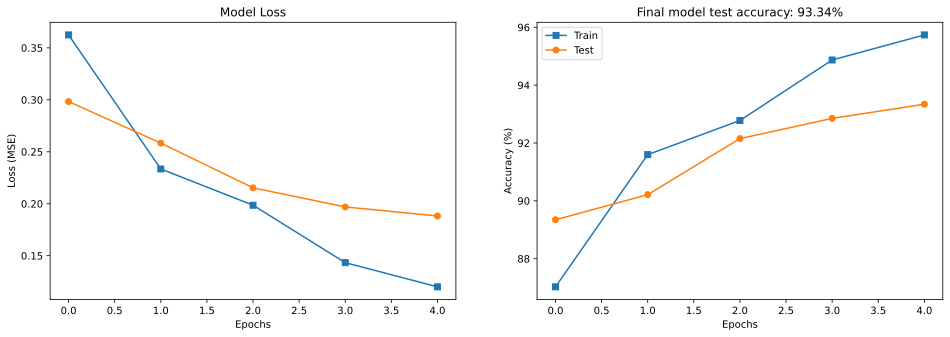

In [17]:
fig, ax = plt.subplots(1,2,figsize=(16,5))

ax[0].plot(train_losses.cpu().detach(), 's-', label = 'Train')
ax[0].plot(test_losses.cpu().detach(), 'o-', label = 'Test')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss (MSE)')
ax[0].set_title('Model Loss')

ax[1].plot(train_accs.cpu().detach(), 's-', label = 'Train')
ax[1].plot(test_accs.cpu().detach(), 'o-', label = 'Test')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy (%)')
ax[1].set_title(f'Final model test accuracy: {test_accs[-1]:.2f}%')
ax[1].legend()

plt.show()

## Preds

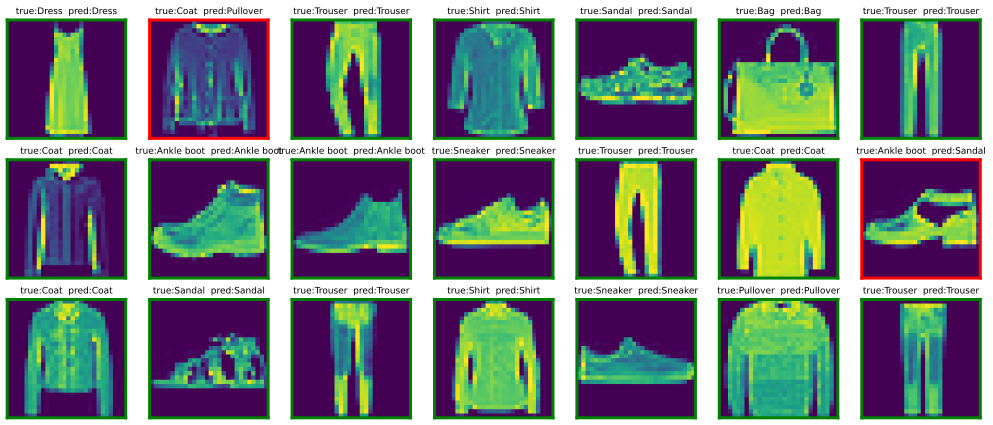

In [20]:
import torch
import numpy as np
import matplotlib.pyplot as plt

def display_preds(net, test_dataloader, class_names=None, device=None, seed=None):
    if seed is not None:
        np.random.seed(seed)

    if device is None:
        device = next(net.parameters()).device

    net.eval()

    xs, ys = [], []
    # zbierz min 21 z test_dataloader
    for xb, yb in test_dataloader:
        xs.append(xb)
        ys.append(yb)
        if sum(t.size(0) for t in xs) >= 21:
            break

    X = torch.cat(xs, dim=0)[:max(21, X.size(0))] if False else torch.cat(xs, dim=0)
    Y = torch.cat(ys, dim=0)

    # wybierz losowe 21 z tego co zebrane
    n = X.size(0)
    idx = np.random.choice(n, 21, replace=False)

    Xs = X[idx]
    Ys = Y[idx]

    with torch.no_grad():
        preds = net(Xs.to(device)).argmax(1).cpu()

    fig, axes = plt.subplots(3, 7, figsize=(14, 6))
    axes = axes.ravel()

    for ax, img, y, p in zip(axes, Xs.cpu(), Ys.cpu(), preds):
        # img: (C,H,W) -> (H,W,C)
        img = img.detach()
        if img.dim() == 3 and img.size(0) in (1,3):
            img_np = img.permute(1,2,0).numpy()
        else:
            img_np = img.numpy()

        # szybkie "żeby było widać" (bez mean/std)
        img_np = np.clip(img_np, 0, 1)

        ax.imshow(img_np.squeeze() if img_np.shape[-1]==1 else img_np)

        yt = int(y); pt = int(p)
        if class_names is not None:
            tname = class_names[yt]
            pname = class_names[pt]
        else:
            tname = str(yt)
            pname = str(pt)

        ax.set_title(f"true:{tname}  pred:{pname}", fontsize=9)

        ok = (yt == pt)
        color = "green" if ok else "red"
        for sp in ax.spines.values():
            sp.set_edgecolor(color)
            sp.set_linewidth(3)

        ax.set_xticks([]); ax.set_yticks([])

    plt.tight_layout()
    plt.show()

display_preds(net, test_dataloader, class_names=train_ds.classes)

## Confusion Matrix

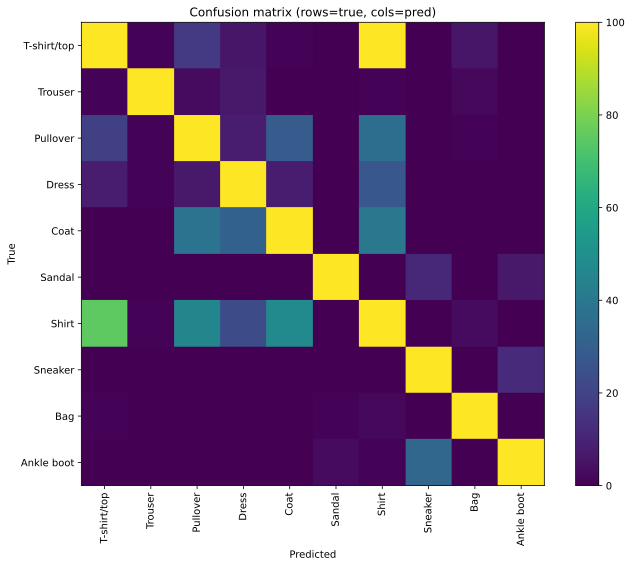

In [19]:
import torch
import numpy as np
import matplotlib.pyplot as plt

@torch.no_grad()
def plot_confusion_matrix(net, test_dataloader, categories, device=None):
    if device is None:
        device = next(net.parameters()).device

    net.eval()
    y_true, y_pred = [], []

    for xb, yb in test_dataloader:
        logits = net(xb.to(device))
        pred = logits.argmax(1).cpu().numpy()
        y_true.append(yb.numpy())
        y_pred.append(pred)

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    n = len(categories)
    cm = np.zeros((n, n), dtype=np.int64)  # rows=true, cols=pred
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation="nearest",vmax=100)
    plt.title("Confusion matrix (rows=true, cols=pred)")
    plt.colorbar()
    plt.xticks(range(n), categories, rotation=90)
    plt.yticks(range(n), categories)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return cm

cm = plot_confusion_matrix(net, test_dataloader, categories=train_ds.classes)

Our model mostly confuses Shirt with T-shirt/top which look simmilar.